### **Momentum Trading**
We have practiced a strategy that buys  "winners" and sells "losers" at each period. This question extends that exercise from buying and selling one stock to several stocks.

Specifically, consider the following strategy:

* At the end of each month, identify the two stocks with lowest returns and two stocks with the highest returns.
* Buy one dollar worth of the winner stocks and sell one dollar worth of the loser stocks.
* Invest the dollar equally in the two winner stocks, so fifty cents in each stock.
* Analogously for the loser stocks.

Compute the mean return for this strategy for Dow stocks. 

In [1]:
import pandas_ta as ta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader.data import DataReader
from datetime import date, datetime, timedelta

In [2]:
close = pd.read_csv('data/dj_stocks_close.csv', parse_dates=['date'], index_col='date')

In [3]:
monthly_close = close.resample('M').last()
monthly_returns = monthly_close.pct_change()

### **Identify two best and worst performing stocks in each period**
In class, we identified when a stock performed better than other stocks. Performed better meant that the stock had higher returns than the other stocks. 

In such applications, the method df.rank() can be used to provide rankings. In this method, the axis option can be set to 'rows' or 'columns'. An additional option that can be provided is ascending = True or  ascending = False.

In [4]:
best = 2
long = (monthly_returns.rank(axis='columns', ascending = False) <= best).astype(int)
short = (monthly_returns.rank(axis='columns', ascending = True) <= best).astype(int)*-1

In [5]:
#  FROM CLASS
pos = (long + short)/best
pos

,MMM,AXP,AMGN,AAPL,BA,CAT,CVX,CSCO,KO,GS,...,NKE,PG,CRM,TRV,UNH,VZ,V,WBA,WMT,DIS
date,,,,,,,,,,,,,,,,,,,,,
2004-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2004-02-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.5,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5
2004-03-31,0.0,0.0,-0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,0.0,0.0,0.0,-0.5,0.0,0.0
2004-04-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.5,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2004-05-31,0.0,0.0,0.0,0.5,0.0,-0.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.5,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-08-31,0.0,0.0,0.5,0.0,0.5,-0.5,0.0,-0.5,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-09-30,0.0,0.0,-0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.5,0.0,0.0,0.0,-0.5,0.0,0.0,0.0,0.0,0.0
2019-10-31,0.0,0.0,0.0,0.5,-0.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.5,0.5,0.0,0.0,0.0,0.0,0.0


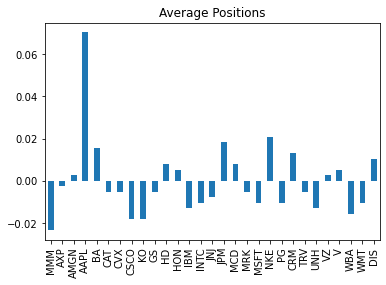

In [6]:
pos.mean().plot(kind='bar',title='Average Positions')
None

In [7]:
# Strategy Returns
lookahead_monthly_returns = monthly_returns.shift(-1)
strat_returns = pos*lookahead_monthly_returns

strat_returns = strat_returns.sum(axis='columns')

In [8]:
# Compute Annualized Mean Strategy Returns
strat_returns.mean()*12
#strat_returns.var()*12

0.0638861289755293